<a href="https://colab.research.google.com/github/Poojitha4795/Social-Media-Analytics-and-Engagement-Prediction-Using-Data-Science/blob/main/major_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import json
import re
import os
import warnings
warnings.filterwarnings("ignore")
print("Libraries imported successfully")

Libraries imported successfully


In [ ]:
gb_videos = pd.read_csv(
    "/content/GBvideos.csv",
    encoding="utf-8",
    on_bad_lines="skip"
)
us_videos = pd.read_csv(
    "/content/USvideos.csv",
    encoding="utf-8",
    on_bad_lines="skip"
)
print("GB videos:", gb_videos.shape)
print("US videos:", us_videos.shape)

GB videos: (7993, 11)
US videos: (7992, 11)


In [ ]:
print("GB columns:")
print(gb_videos.columns.tolist())
print("\nUS columns:")
print(us_videos.columns.tolist())

GB columns:
['video_id', 'title', 'channel_title', 'category_id', 'tags', 'views', 'likes', 'dislikes', 'comment_total', 'thumbnail_link', 'date']

US columns:
['video_id', 'title', 'channel_title', 'category_id', 'tags', 'views', 'likes', 'dislikes', 'comment_total', 'thumbnail_link', 'date']


In [ ]:
gb_videos["country"] = "GB"
us_videos["country"] = "US"
print(gb_videos[["video_id", "country"]].head())
print(us_videos[["video_id", "country"]].head())

      video_id country
0  jt2OHQh0HoQ      GB
1  AqokkXoa7uE      GB
2  YPVcg45W0z4      GB
3  T_PuZBdT2iM      GB
4  NsjsmgmbCfc      GB
      video_id country
0  XpVt6Z1Gjjo      US
1  K4wEI5zhHB0      US
2  cLdxuaxaQwc      US
3  WYYvHb03Eog      US
4  sjlHnJvXdQs      US


In [ ]:
videos = pd.concat(
    [gb_videos, us_videos],
    ignore_index=True
)
print("Combined dataset shape:", videos.shape)

Combined dataset shape: (15985, 12)


In [ ]:
videos = videos.drop_duplicates(
    subset=["video_id", "country"]
).reset_index(drop=True)
print("Shape after removing duplicates:", videos.shape)

Shape after removing duplicates: (4100, 12)


In [ ]:
numeric_columns = [
    "category_id",
    "views",
    "likes",
    "dislikes",
    "comment_total"
]
for column in numeric_columns:
    videos[column] = pd.to_numeric(
        videos[column],
        errors="coerce"
    )
print(videos[numeric_columns].dtypes)

category_id      int64
views            int64
likes            int64
dislikes         int64
comment_total    int64
dtype: object


In [ ]:
print(videos.isnull().sum())

video_id          0
title             0
channel_title     0
category_id       0
tags              0
views             0
likes             0
dislikes          0
comment_total     0
thumbnail_link    0
date              0
country           0
dtype: int64


In [ ]:
for column in ["views", "likes", "dislikes", "comment_total"]:
    videos[column] = videos[column].fillna(0)
videos["title"] = videos["title"].fillna("")
videos["tags"] = videos["tags"].fillna("")
videos["channel_title"] = videos["channel_title"].fillna("Unknown")
print("Missing values handled")

Missing values handled


In [ ]:
with open(
    "/content/GB_category_id.json",
    "r",
    encoding="utf-8"
) as file:
    gb_categories = json.load(file)
with open(
    "/content/US_category_id.json",
    "r",
    encoding="utf-8"
) as file:
    us_categories = json.load(file)
print("Category files loaded")

Category files loaded


In [ ]:
gb_category_map = {
    int(item["id"]): item["snippet"]["title"]
    for item in gb_categories["items"]
}
us_category_map = {
    int(item["id"]): item["snippet"]["title"]
    for item in us_categories["items"]
}
print("GB categories:", len(gb_category_map))
print("US categories:", len(us_category_map))

GB categories: 31
US categories: 32


In [ ]:
def get_category(row):
    if row["country"] == "GB":
        return gb_category_map.get(
            int(row["category_id"]),
            "Unknown"
        )
    else:
        return us_category_map.get(
            int(row["category_id"]),
            "Unknown"
        )
videos["category_name"] = videos.apply(
    get_category,
    axis=1
)
print(
    videos[
        ["country", "category_id", "category_name"]
    ].head(10)
)

  country  category_id         category_name
0      GB           28  Science & Technology
1      GB           24         Entertainment
2      GB           24         Entertainment
3      GB            1      Film & Animation
4      GB           26         Howto & Style
5      GB           24         Entertainment
6      GB           26         Howto & Style
7      GB           17                Sports
8      GB           22        People & Blogs
9      GB           10                 Music


In [ ]:
videos["title_length"] = videos["title"].str.len()
videos["title_word_count"] = (
    videos["title"]
    .str.split()
    .str.len()
)
videos["title_uppercase_count"] = (
    videos["title"]
    .apply(lambda x: sum(1 for c in x if c.isupper()))
)
videos["has_question"] = (
    videos["title"]
    .str.contains(r"\?", regex=True)
    .astype(int)
)
videos["has_exclamation"] = (
    videos["title"]
    .str.contains(r"!", regex=True)
    .astype(int)
)
print(
    videos[
        [
            "title",
            "title_length",
            "title_word_count",
            "has_question",
            "has_exclamation"
        ]
    ].head()
)

                                               title  title_length  \
0  Live Apple Event - Apple September Event 2017 ...            90   
1  Holly and Phillip Meet Samantha the Sex Robot ...            60   
2                    My DNA Test Results! I'm WHAT?!            31   
3  getting into a conversation in a language you ...            76   
4                               Baby Name Challenge!            20   

   title_word_count  has_question  has_exclamation  
0                18             0                0  
1                11             0                0  
2                 6             1                1  
3                13             0                0  
4                 3             0                1  


In [ ]:
videos["like_rate"] = np.where(
    videos["views"] > 0,
    videos["likes"] / videos["views"],
    0
)
videos["dislike_rate"] = np.where(
    videos["views"] > 0,
    videos["dislikes"] / videos["views"],
    0
)
videos["comment_rate"] = np.where(
    videos["views"] > 0,
    videos["comment_total"] / videos["views"],
    0
)
videos["engagement_rate"] = np.where(
    videos["views"] > 0,
    (
        videos["likes"]
        + videos["dislikes"]
        + videos["comment_total"]
    ) / videos["views"],
    0
)
print(
    videos[
        [
            "views",
            "likes",
            "comment_total",
            "engagement_rate"
        ]
    ].head()
)

     views  likes  comment_total  engagement_rate
0  7426393  78240            705         0.012455
1   494203   2651              0         0.008013
2   142819  13119           1141         0.100904
3  1580028  65729           3598         0.044845
4    40592   5019            490         0.137121


In [ ]:
videos["viral_score"] = np.where(
    videos["views"] > 0,
    (
        0.6 * (videos["likes"] / videos["views"])
        +
        0.4 * (videos["comment_total"] / videos["views"])
    ),
    0
)
print(
    videos[
        [
            "title",
            "viral_score"
        ]
    ].sort_values(
        "viral_score",
        ascending=False
    ).head(10)
)

                                              title  viral_score
1627          Taylor Swift - Gorgeous (Lyric Video)     0.221565
3953          Taylor Swift - Gorgeous (Lyric Video)     0.214023
3625                   Tour Documentary - Episode 2     0.169859
874                                    dodie - 6/10     0.148905
2875                                   dodie - 6/10     0.148005
900                            1,000,000 THANK YOU!     0.141936
2888                           1,000,000 THANK YOU!     0.141717
909                to all the books I'll never read     0.141259
3869  Louis Tomlinson - Just Like You (Lyric Video)     0.140749
3323                   LAY 레이 'SHEEP (羊)' MV Teaser     0.136775


In [ ]:
viral_threshold = videos["viral_score"].quantile(0.75)
videos["viral"] = (
    videos["viral_score"] >= viral_threshold
).astype(int)
print("Viral threshold:", viral_threshold)
print(
    videos["viral"].value_counts()
)

Viral threshold: 0.03737803745713399
viral
0    3075
1    1025
Name: count, dtype: int64


In [ ]:
category_performance = (
    videos
    .groupby("category_name")
    .agg(
        videos=("video_id", "count"),
        total_views=("views", "sum"),
        average_views=("views", "mean"),
        average_likes=("likes", "mean"),
        average_comments=("comment_total", "mean"),
        average_engagement=("engagement_rate", "mean"),
        average_viral_score=("viral_score", "mean")
    )
    .sort_values(
        "average_viral_score",
        ascending=False
    )
)
print(category_performance.head(10))

                      videos  total_views  average_views  average_likes  \
category_name                                                             
Music                    615    523469102  851169.271545   50769.188618   
Howto & Style            514    192036080  373611.050584   22019.684825   
Comedy                   337    307542079  912587.771513   48334.198813   
People & Blogs           502    287554131  572816.994024   24863.500000   
Education                140     54538330  389559.500000   14159.150000   
Entertainment            796    465665663  585007.114322   20988.047739   
Pets & Animals            56     27448507  490151.910714   13827.607143   
Gaming                    94     39885207  424310.712766   15678.446809   
Film & Animation         177    106884564  603867.593220   16395.689266   
Science & Technology     202    115191443  570254.668317   15638.564356   

                      average_comments  average_engagement  \
category_name                        

In [ ]:
country_performance = (
    videos
    .groupby("country")
    .agg(
        videos=("video_id", "count"),
        total_views=("views", "sum"),
        average_views=("views", "mean"),
        average_likes=("likes", "mean"),
        average_comments=("comment_total", "mean"),
        average_engagement=("engagement_rate", "mean"),
        average_viral_score=("viral_score", "mean")
    )
)
print(country_performance)

         videos  total_views  average_views  average_likes  average_comments  \
country                                                                        
GB         1736   1088460944  626993.631336   27023.999424       3517.244816   
US         2364   1301327262  550476.845178   23660.027496       3262.802876   

         average_engagement  average_viral_score  
country                                           
GB                 0.049546             0.027832  
US                 0.046791             0.026014  


In [ ]:
gb_comments = pd.read_csv(
    "/content/GBcomments.csv",
    encoding="utf-8",
    on_bad_lines="skip",
    engine="python"
)
print(gb_comments.shape)
us_comments = pd.read_csv(
  "/content/UScomments.csv",
    encoding="utf-8",
    on_bad_lines="skip",
    engine="python"
)
print(us_comments.shape)

(354785, 4)
(269553, 4)


In [ ]:
gb_comments["country"] = "GB"
us_comments["country"] = "US"
comments = pd.concat(
    [gb_comments, us_comments],
    ignore_index=True
)
print("Combined comments:", comments.shape)

Combined comments: (624338, 5)


In [ ]:
comments["comment_text"] = (
    comments["comment_text"]
    .fillna("")
    .astype(str)
)
comments["comment_text"] = (
    comments["comment_text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
comments["likes"] = pd.to_numeric(
    comments["likes"],
    errors="coerce"
).fillna(0)
comments["replies"] = pd.to_numeric(
    comments["replies"],
    errors="coerce"
).fillna(0)
print(comments.head())

      video_id                                       comment_text  likes  \
0  jt2OHQh0HoQ  It's more accurate to call it the M+ (1000) be...    0.0   
1  jt2OHQh0HoQ              To be there with a samsung phone\n😂😂😂    1.0   
2  jt2OHQh0HoQ  Thank gosh, a place I can watch it without hav...    0.0   
3  jt2OHQh0HoQ  What happened to the home button on the iPhone...    0.0   
4  jt2OHQh0HoQ  Power is the disease. Care is the cure. Keep c...    0.0   

   replies country  
0      0.0      GB  
1      0.0      GB  
2      0.0      GB  
3      0.0      GB  
4      0.0      GB  


In [ ]:
comments = comments[
    comments["comment_text"].str.len() > 0
].copy()
comments = comments.reset_index(drop=True)
print("Comments after cleaning:", comments.shape)

Comments after cleaning: (624320, 5)


In [ ]:
from textblob import TextBlob
print("TextBlob imported successfully")

TextBlob imported successfully


In [ ]:
!pip install textblob

In [ ]:
def get_sentiment(text):
    try:
        polarity = TextBlob(text).sentiment.polarity
        if polarity > 0.05:
            return "Positive"
        elif polarity < -0.05:
            return "Negative"
        else:
            return "Neutral"
    except:
        return "Neutral"

In [ ]:
np.random.seed(42)
comment_sample = comments.sample(
    n=min(100000, len(comments)),
    random_state=42
).copy()
print("Comments selected for NLP:", len(comment_sample))

Comments selected for NLP: 100000


In [ ]:
comment_sample["sentiment"] = (
    comment_sample["comment_text"]
    .apply(get_sentiment)
)
print(
    comment_sample["sentiment"]
    .value_counts()
)

sentiment
Neutral     43899
Positive    43077
Negative    13024
Name: count, dtype: int64


In [ ]:
comment_sample["sentiment_score"] = (
    comment_sample["comment_text"]
    .apply(
        lambda x: TextBlob(x).sentiment.polarity
    )
)
print(
    comment_sample[
        [
            "comment_text",
            "sentiment",
            "sentiment_score"
        ]
    ].head()
)

                                          comment_text sentiment  \
144037                           waa that dytto i seen   Neutral   
394550                                  Chiefs Kingdom   Neutral   
155347                Where do you get your wigs from?   Neutral   
9464    AJ makes Vuj and Poet look mad underweight lol  Positive   
595149                        she is super annoying...  Negative   

        sentiment_score  
144037         0.000000  
394550         0.000000  
155347         0.000000  
9464           0.087500  
595149        -0.233333  


In [ ]:
relatable_words = [
    "same",
    "me too",
    "literally me",
    "i relate",
    "relatable",
    "this is me",
    "so true",
    "exactly",
    "felt this",
    "feel this",
    "my life",
    "this happens to me",
    "story of my life",
    "can relate",
    "too real"
]
def classify_relatability(text):
    text = text.lower()
    for phrase in relatable_words:
        if phrase in text:
            return "Relatable"
    return "Neutral"
comment_sample["relatability"] = (
    comment_sample["comment_text"]
    .apply(classify_relatability)
)
print(
    comment_sample["relatability"]
    .value_counts()
)

relatability
Neutral      97912
Relatable     2088
Name: count, dtype: int64


In [ ]:
comment_summary = (
    comment_sample
    .groupby("video_id")
    .agg(
        comment_count=("comment_text", "count"),
        average_sentiment=("sentiment_score", "mean"),
        positive_comments=(
            "sentiment",
            lambda x: (x == "Positive").sum()
        ),
        negative_comments=(
            "sentiment",
            lambda x: (x == "Negative").sum()
        ),
        relatable_comments=(
            "relatability",
            lambda x: (x == "Relatable").sum()
        )
    )
    .reset_index()
)
print(comment_summary.head())

      video_id  comment_count  average_sentiment  positive_comments  \
0  --y69Ui8xwM             43           0.214510                 20   
1  -1fzGnFwz9M             54           0.177671                 31   
2  -2hRYEFiPSA            123           0.234056                 79   
3  -6Zc8Co2H3w            127           0.208389                 58   
4  -C-LJUD2LWU             20           0.295270                 14   

   negative_comments  relatable_comments  
0                  3                   0  
1                  6                   2  
2                  9                   3  
3                 10                   1  
4                  0                   1  


In [ ]:
comment_summary["relatable_percentage"] = np.where(
    comment_summary["comment_count"] > 0,
    (
        comment_summary["relatable_comments"]
        /
        comment_summary["comment_count"]
    ) * 100,
    0
)
print(
    comment_summary.sort_values(
        "relatable_percentage",
        ascending=False
    ).head(10)
)

         video_id  comment_count  average_sentiment  positive_comments  \
176   6IlVWeI_0yo              2           0.087500                  1   
692   R4UbWxXKUVM             27           0.256153                 21   
1154  hP8_5cJujRQ             95           0.089876                 50   
369   E-NxvaVWjBM              6           0.206376                  4   
669   Q0RVBTb6wTQ             17           0.158340                  7   
1038  ciXIdvfejn4             62           0.268671                 41   
1191  jG2Qf-DIofk             19           0.195608                 10   
1546  z1g7n0QZvvE              5           0.113889                  3   
1431  u6iVspBWzZU             97           0.104490                 49   
91    2caEL5ATPX4             12           0.302851                  8   

      negative_comments  relatable_comments  relatable_percentage  
176                   0                   1             50.000000  
692                   2                  12      

In [ ]:
analysis_df = videos.merge(
    comment_summary,
    on="video_id",
    how="left"
)
analysis_df = analysis_df.fillna({
    "comment_count": 0,
    "average_sentiment": 0,
    "positive_comments": 0,
    "negative_comments": 0,
    "relatable_comments": 0,
    "relatable_percentage": 0
})
print("Final analysis dataset:", analysis_df.shape)

Final analysis dataset: (4100, 30)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
print("Machine learning libraries imported")

Machine learning libraries imported


In [ ]:
features = [
    "title_length",
    "title_word_count",
    "title_uppercase_count",
    "has_question",
    "has_exclamation",
    "like_rate",
    "dislike_rate",
    "comment_rate",
    "engagement_rate",
    "category_id"
]
model_data = analysis_df[
    features + ["viral"]
].copy()
model_data = model_data.replace(
    [np.inf, -np.inf],
    np.nan
)
model_data = model_data.dropna()
print(model_data.shape)

(4100, 11)


In [ ]:
X = model_data[features]
y = model_data["viral"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 3280
Testing rows: 820


In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)
model.fit(
    X_train,
    y_train
)
print("Model trained successfully")

Model trained successfully


In [ ]:
predictions = model.predict(X_test)
accuracy = accuracy_score(
    y_test,
    predictions
)
print("Model Accuracy:", round(accuracy, 4))
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        predictions
    )
)

Model Accuracy: 0.9988

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       615
           1       1.00      1.00      1.00       205

    accuracy                           1.00       820
   macro avg       1.00      1.00      1.00       820
weighted avg       1.00      1.00      1.00       820



In [ ]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})
feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)
print(feature_importance)

                 feature  importance
8        engagement_rate    0.426728
5              like_rate    0.423793
7           comment_rate    0.113347
6           dislike_rate    0.014244
0           title_length    0.007344
9            category_id    0.006121
2  title_uppercase_count    0.004499
1       title_word_count    0.002321
4        has_exclamation    0.001288
3           has_question    0.000316


In [ ]:
def hook_type(row):
    if row["has_question"] == 1:
        return "Question Hook"
    elif row["has_exclamation"] == 1:
        return "Exclamation Hook"
    else:
        return "Standard Hook"
analysis_df["hook_type"] = analysis_df.apply(
    hook_type,
    axis=1
)
analysis_df["title_format"] = np.where(
    analysis_df["title_word_count"] >=
    analysis_df["title_word_count"].median(),
    "Long Title",
    "Short Title"
)
print(
    analysis_df[
        ["title", "hook_type", "title_format"]
    ].head()
)

                                               title         hook_type  \
0  Live Apple Event - Apple September Event 2017 ...     Standard Hook   
1  Holly and Phillip Meet Samantha the Sex Robot ...     Standard Hook   
2                    My DNA Test Results! I'm WHAT?!     Question Hook   
3  getting into a conversation in a language you ...     Standard Hook   
4                               Baby Name Challenge!  Exclamation Hook   

  title_format  
0   Long Title  
1   Long Title  
2  Short Title  
3   Long Title  
4  Short Title  


In [ ]:
hook_analysis = (
    analysis_df
    .groupby("hook_type")
    .agg(
        videos=("video_id", "count"),
        average_views=("views", "mean"),
        average_likes=("likes", "mean"),
        average_comments=("comment_total", "mean"),
        average_engagement=("engagement_rate", "mean"),
        average_viral_score=("viral_score", "mean")
    )
    .sort_values(
        "average_viral_score",
        ascending=False
    )
)
print(hook_analysis)

                  videos  average_views  average_likes  average_comments  \
hook_type                                                                  
Exclamation Hook     563  524312.992895   25398.266430       3314.898757   
Question Hook        244  534620.631148   23542.352459       3349.352459   
Standard Hook       3293  596462.969025   25144.977224       3381.619496   

                  average_engagement  average_viral_score  
hook_type                                                  
Exclamation Hook            0.054714             0.030812  
Question Hook               0.053482             0.029885  
Standard Hook               0.046393             0.025865  


In [ ]:
title_format_analysis = (
    analysis_df
    .groupby("title_format")
    .agg(
        videos=("video_id", "count"),
        average_views=("views", "mean"),
        average_likes=("likes", "mean"),
        average_comments=("comment_total", "mean"),
        average_engagement=("engagement_rate", "mean"),
        average_viral_score=("viral_score", "mean")
    )
)
print(title_format_analysis)

              videos  average_views  average_likes  average_comments  \
title_format                                                           
Long Title      2333  518211.063866   18933.793399       2509.477925   
Short Title     1767  668252.288625   33205.109225       4507.408602   

              average_engagement  average_viral_score  
title_format                                           
Long Title              0.041600             0.023081  
Short Title             0.056351             0.031672  


In [ ]:
best_category = (
    category_performance
    .sort_values(
        "average_viral_score",
        ascending=False
    )
    .index[0]
)
best_hook = (
    hook_analysis
    .sort_values(
        "average_viral_score",
        ascending=False
    )
    .index[0]
)
best_title_format = (
    title_format_analysis
    .sort_values(
        "average_viral_score",
        ascending=False
    )
    .index[0]
)
print("Recommended Category:", best_category)
print("Recommended Hook:", best_hook)
print("Recommended Title Format:", best_title_format)

Recommended Category: Music
Recommended Hook: Exclamation Hook
Recommended Title Format: Short Title


In [ ]:
strategy = pd.DataFrame({
    "Recommendation": [
        "Best Category",
        "Best Hook",
        "Best Title Format"
    ],
    "Value": [
        best_category,
        best_hook,
        best_title_format
    ]
})
print(strategy)

      Recommendation             Value
0      Best Category             Music
1          Best Hook  Exclamation Hook
2  Best Title Format       Short Title


In [ ]:
tag_data = videos[
    ["video_id", "tags"]
].copy()
tag_data["tags"] = (
    tag_data["tags"]
    .fillna("")
    .astype(str)
)

tag_data["tag_list"] = tag_data["tags"].apply(
    lambda x: [
        tag.strip().lower()
        for tag in x.split("|")
        if tag.strip()
    ]
)
print(tag_data.head())

      video_id                                               tags  \
0  jt2OHQh0HoQ  apple events|apple event|iphone 8|iphone x|iph...   
1  AqokkXoa7uE  this morning|interview|holly willoughby|philli...   
2  YPVcg45W0z4  emmablackery|emma blackery|emma|blackery|briti...   
3  T_PuZBdT2iM  skit|korean|language|conversation|esl|japanese...   
4  NsjsmgmbCfc  sprinkleofglitter|sprinkle of glitter|baby gli...   

                                            tag_list  
0  [apple events, apple event, iphone 8, iphone x...  
1  [this morning, interview, holly willoughby, ph...  
2  [emmablackery, emma blackery, emma, blackery, ...  
3  [skit, korean, language, conversation, esl, ja...  
4  [sprinkleofglitter, sprinkle of glitter, baby ...  


In [ ]:
all_tags = []
for tag_list in tag_data["tag_list"]:
    all_tags.extend(tag_list)
tag_counts = (
    pd.Series(all_tags)
    .value_counts()
)
print(tag_counts.head(20))

funny        428
comedy       322
[none]       232
vlog         187
makeup       171
2017         167
how to       159
music        151
interview    146
beauty       139
humor        138
tutorial     138
trailer      137
news         127
video        123
celebrity    121
review       120
food         119
pop          113
talk show    112
Name: count, dtype: int64


In [ ]:
top_topics = (
    tag_counts
    .head(20)
    .reset_index()
)
top_topics.columns = [
    "topic",
    "frequency"
]
print(top_topics)

        topic  frequency
0       funny        428
1      comedy        322
2      [none]        232
3        vlog        187
4      makeup        171
5        2017        167
6      how to        159
7       music        151
8   interview        146
9      beauty        139
10      humor        138
11   tutorial        138
12    trailer        137
13       news        127
14      video        123
15  celebrity        121
16     review        120
17       food        119
18        pop        113
19  talk show        112


In [ ]:
import matplotlib.pyplot as plt
print("Matplotlib imported")

Matplotlib imported


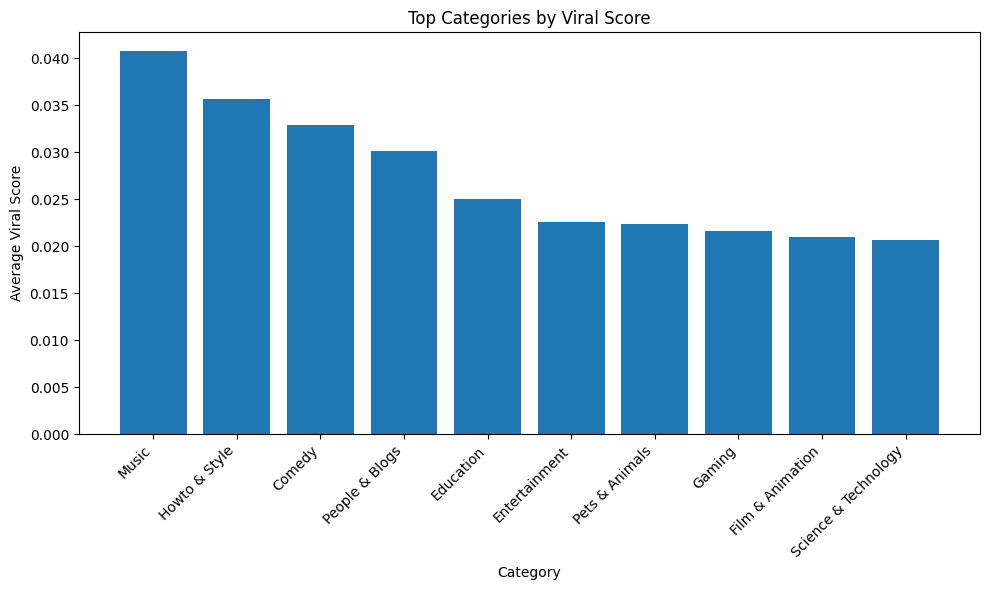

In [ ]:
plot_data = (
    category_performance
    .sort_values(
        "average_viral_score",
        ascending=False
    )
    .head(10)
)
plt.figure(figsize=(10, 6))
plt.bar(
    plot_data.index,
    plot_data["average_viral_score"]
)
plt.xticks(
    rotation=45,
    ha="right"
)
plt.xlabel("Category")
plt.ylabel("Average Viral Score")
plt.title("Top Categories by Viral Score")
plt.tight_layout()
plt.show()

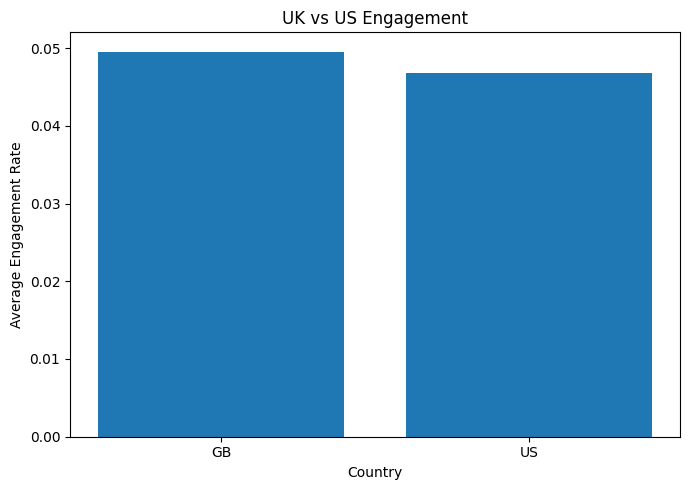

In [ ]:
plt.figure(figsize=(7, 5))
plt.bar(
    country_performance.index,
    country_performance["average_engagement"]
)
plt.xlabel("Country")
plt.ylabel("Average Engagement Rate")
plt.title("UK vs US Engagement")
plt.tight_layout()
plt.show()

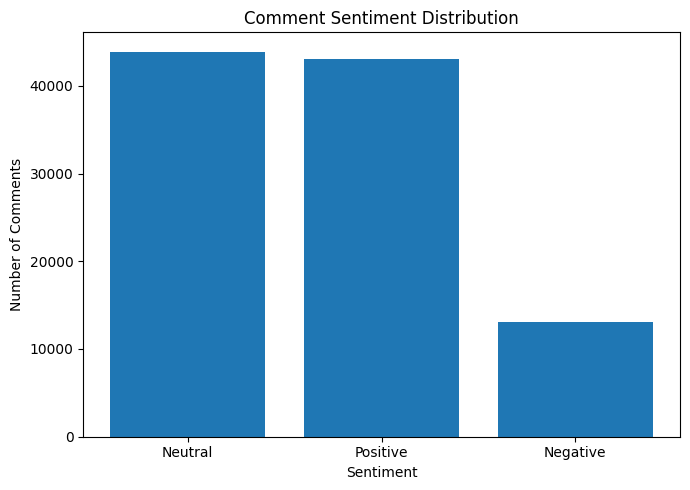

In [ ]:
sentiment_counts = (
    comment_sample["sentiment"]
    .value_counts()
)
plt.figure(figsize=(7, 5))
plt.bar(
    sentiment_counts.index,
    sentiment_counts.values
)
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.title("Comment Sentiment Distribution")
plt.tight_layout()
plt.show()

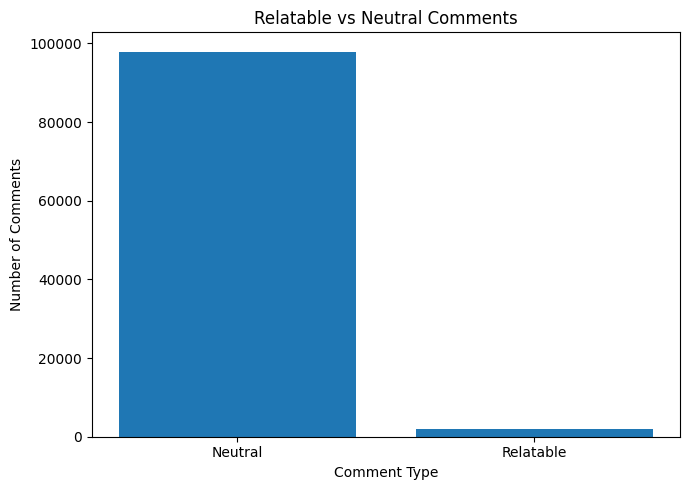

In [ ]:
relatable_counts = (
    comment_sample["relatability"]
    .value_counts()
)
plt.figure(figsize=(7, 5))
plt.bar(
    relatable_counts.index,
    relatable_counts.values
)
plt.xlabel("Comment Type")
plt.ylabel("Number of Comments")
plt.title("Relatable vs Neutral Comments")
plt.tight_layout()
plt.show()

In [ ]:
os.makedirs(
    "project_output",
    exist_ok=True
)
analysis_df.to_csv(
    "project_output/youtube_analysis.csv",
    index=False
)
comment_sample.to_csv(
    "project_output/comment_sentiment_analysis.csv",
    index=False
)
category_performance.to_csv(
    "project_output/category_performance.csv"
)
country_performance.to_csv(
    "project_output/country_performance.csv"
)
feature_importance.to_csv(
    "project_output/feature_importance.csv",
    index=False
)
strategy.to_csv(
    "project_output/content_strategy.csv",
    index=False
)
top_topics.to_csv(
    "project_output/top_topics.csv",
    index=False
)
print("All output files saved successfully")

All output files saved successfully


In [ ]:
print("DATA-DRIVEN SOCIAL ENGAGEMENT PROJECT")
print("\nTotal Videos:", len(analysis_df))
print(
    "Total Comments Used for NLP:",
    len(comment_sample)
)
print(
    "Number of Categories:",
    analysis_df["category_name"].nunique()
)
print(
    "Best Category:",
    best_category
)
print(
    "Best Hook:",
    best_hook
)
print(
    "Best Title Format:",
    best_title_format
)
print(
    "Model Accuracy:",
    round(accuracy, 4)
)
print("\nProject processing completed successfully.")

DATA-DRIVEN SOCIAL ENGAGEMENT PROJECT

Total Videos: 4100
Total Comments Used for NLP: 100000
Number of Categories: 17
Best Category: Music
Best Hook: Exclamation Hook
Best Title Format: Short Title
Model Accuracy: 0.9988

Project processing completed successfully.


In [ ]:
import os
print("Current folder:")
print(os.getcwd())
print("\nFolders and files:")
for item in os.listdir():
    print(item)

Current folder:
/content

Folders and files:
.config
USvideos.csv
UScomments.csv
content_strategy.csv
GBcomments.csv
comment_sentiment_analysis.csv
US_category_id.json
GBvideos.csv
top_topics.csv
feature_importance.csv
youtube_analysis.csv
project_output
category_performance.csv
country_performance.csv
GB_category_id.json
sample_data


In [ ]:
print("\nFiles inside project_output:")
for file in os.listdir("project_output"):
    print(file)


Files inside project_output:
content_strategy.csv
comment_sentiment_analysis.csv
top_topics.csv
feature_importance.csv
youtube_analysis.csv
category_performance.csv
country_performance.csv


In [ ]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 82.9 MB/s eta 0:00:00


In [ ]:
%%writefile dashboard.py

import streamlit as st
import pandas as pd


# ============================================================
# 1. PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Data-Driven Social Engagement Analytics",
    page_icon="📊",
    layout="wide"
)


# ============================================================
# 2. LOAD OUTPUT FILES
# ============================================================

OUTPUT_PATH = "project_output/"


df = pd.read_csv(
    OUTPUT_PATH + "youtube_analysis.csv"
)

sentiment_df = pd.read_csv(
    OUTPUT_PATH + "comment_sentiment_analysis.csv"
)

category_df = pd.read_csv(
    OUTPUT_PATH + "category_performance.csv"
)

country_df = pd.read_csv(
    OUTPUT_PATH + "country_performance.csv"
)

feature_df = pd.read_csv(
    OUTPUT_PATH + "feature_importance.csv"
)

strategy_df = pd.read_csv(
    OUTPUT_PATH + "content_strategy.csv"
)

topics_df = pd.read_csv(
    OUTPUT_PATH + "top_topics.csv"
)


# ============================================================
# 3. HELPER FUNCTION
# ============================================================

def find_column(dataframe, possible_names):

    for name in possible_names:

        if name in dataframe.columns:
            return name

    return None


# ============================================================
# 4. FIND REQUIRED COLUMNS
# ============================================================

views_col = find_column(
    df,
    ["views", "view_count"]
)

likes_col = find_column(
    df,
    ["likes", "like_count"]
)

comments_col = find_column(
    df,
    ["comment_total", "comments", "comment_count"]
)

engagement_col = find_column(
    df,
    ["engagement_rate", "engagement"]
)

viral_score_col = find_column(
    df,
    ["viral_score", "viral_coefficient"]
)

viral_col = find_column(
    df,
    ["viral", "is_viral"]
)

country_col = find_column(
    df,
    ["country", "Country"]
)

category_col = find_column(
    df,
    ["category_name", "category", "Category"]
)

title_col = find_column(
    df,
    ["title", "video_title"]
)

channel_col = find_column(
    df,
    ["channel_title", "channel_name", "channel"]
)


# ============================================================
# 5. CHECK REQUIRED COLUMNS
# ============================================================

required_columns = {
    "Views": views_col,
    "Likes": likes_col,
    "Comments": comments_col,
    "Engagement": engagement_col,
    "Viral Score": viral_score_col,
    "Country": country_col,
    "Category": category_col
}


missing_columns = [
    name
    for name, column in required_columns.items()
    if column is None
]


if missing_columns:

    st.error(
        "The following required columns were not found: "
        + ", ".join(missing_columns)
    )

    st.write(
        "Columns available in youtube_analysis.csv:"
    )

    st.write(
        df.columns.tolist()
    )

    st.stop()


# ============================================================
# 6. DASHBOARD TITLE
# ============================================================

st.title(
    "📊 Data-Driven Social Engagement Analytics"
)

st.subheader(
    "YouTube Content Performance, Virality and Audience Sentiment"
)

st.write(
    "Interactive dashboard based on the completed YouTube analysis."
)


# ============================================================
# 7. SIDEBAR FILTERS
# ============================================================

st.sidebar.header(
    "🎯 Dashboard Filters"
)


country_values = sorted(
    df[country_col]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)


category_values = sorted(
    df[category_col]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)


selected_country = st.sidebar.selectbox(
    "Select Country",
    ["All"] + country_values
)


selected_category = st.sidebar.selectbox(
    "Select Category",
    ["All"] + category_values
)


# ============================================================
# 8. APPLY FILTERS
# ============================================================

filtered_df = df.copy()


if selected_country != "All":

    filtered_df = filtered_df[
        filtered_df[country_col].astype(str)
        == selected_country
    ]


if selected_category != "All":

    filtered_df = filtered_df[
        filtered_df[category_col].astype(str)
        == selected_category
    ]


# ============================================================
# 9. MAIN KPIs
# ============================================================

st.header(
    "📌 Key Performance Indicators"
)


col1, col2, col3, col4 = st.columns(4)


with col1:

    st.metric(
        "Total Videos",
        f"{len(filtered_df):,}"
    )


with col2:

    st.metric(
        "Total Views",
        f"{filtered_df[views_col].sum():,.0f}"
    )


with col3:

    st.metric(
        "Average Engagement",
        f"{filtered_df[engagement_col].mean():.4f}"
    )


with col4:

    st.metric(
        "Average Viral Score",
        f"{filtered_df[viral_score_col].mean():.6f}"
    )


# ============================================================
# 10. ADDITIONAL KPIs
# ============================================================

st.header(
    "📈 Additional Performance Metrics"
)


col1, col2, col3, col4 = st.columns(4)


with col1:

    st.metric(
        "Total Likes",
        f"{filtered_df[likes_col].sum():,.0f}"
    )


with col2:

    st.metric(
        "Total Comments",
        f"{filtered_df[comments_col].sum():,.0f}"
    )


with col3:

    st.metric(
        "Average Views",
        f"{filtered_df[views_col].mean():,.0f}"
    )


with col4:

    if viral_col is not None:

        st.metric(
            "Viral Videos",
            f"{filtered_df[viral_col].sum():,.0f}"
        )

    else:

        st.metric(
            "Viral Videos",
            "N/A"
        )


# ============================================================
# 11. CATEGORY PERFORMANCE
# ============================================================

st.header(
    "🏆 Category Performance"
)


category_performance = (
    filtered_df
    .groupby(category_col)
    .agg(
        Average_Viral_Score=(
            viral_score_col,
            "mean"
        ),
        Average_Engagement=(
            engagement_col,
            "mean"
        ),
        Total_Views=(
            views_col,
            "sum"
        )
    )
    .sort_values(
        "Average_Viral_Score",
        ascending=False
    )
)


st.bar_chart(
    category_performance[
        "Average_Viral_Score"
    ].head(10)
)


st.dataframe(
    category_performance,
    use_container_width=True
)


# ============================================================
# 12. ENGAGEMENT BY CATEGORY
# ============================================================

st.header(
    "📈 Engagement by Category"
)


engagement_category = (
    filtered_df
    .groupby(category_col)[engagement_col]
    .mean()
    .sort_values(
        ascending=False
    )
    .head(10)
)


st.bar_chart(
    engagement_category
)


# ============================================================
# 13. COUNTRY PERFORMANCE
# ============================================================

st.header(
    "🌍 Country Performance"
)


country_performance = (
    df
    .groupby(country_col)
    .agg(
        Average_Views=(
            views_col,
            "mean"
        ),
        Average_Engagement=(
            engagement_col,
            "mean"
        ),
        Average_Viral_Score=(
            viral_score_col,
            "mean"
        )
    )
)


st.bar_chart(
    country_performance[
        "Average_Engagement"
    ]
)


st.dataframe(
    country_performance,
    use_container_width=True
)


# ============================================================
# 14. SENTIMENT ANALYSIS
# ============================================================

st.header(
    "😊 Audience Sentiment Analysis"
)


sentiment_col = find_column(
    sentiment_df,
    ["sentiment", "Sentiment"]
)


if sentiment_col is not None:

    sentiment_counts = (
        sentiment_df[sentiment_col]
        .value_counts()
    )

    st.bar_chart(
        sentiment_counts
    )

    st.dataframe(
        sentiment_counts.rename(
            "Comment Count"
        ),
        use_container_width=True
    )

else:

    st.warning(
        "Sentiment column was not found."
    )


# ============================================================
# 15. RELATABILITY ANALYSIS
# ============================================================

st.header(
    "💬 Audience Relatability"
)


relatability_col = find_column(
    sentiment_df,
    ["relatability", "Relatability"]
)


if relatability_col is not None:

    relatability_counts = (
        sentiment_df[relatability_col]
        .value_counts()
    )

    st.bar_chart(
        relatability_counts
    )

    st.dataframe(
        relatability_counts.rename(
            "Comment Count"
        ),
        use_container_width=True
    )

else:

    st.warning(
        "Relatability column was not found."
    )


# ============================================================
# 16. TOP CONTENT TOPICS
# ============================================================

st.header(
    "🔥 Top Content Topics"
)


st.dataframe(
    topics_df.head(20),
    use_container_width=True
)


# ============================================================
# 17. VIRALITY FACTORS
# ============================================================

st.header(
    "🤖 Factors Influencing Virality"
)


feature_col = find_column(
    feature_df,
    ["feature", "Feature"]
)


importance_col = find_column(
    feature_df,
    ["importance", "Importance"]
)


if feature_col is not None and importance_col is not None:

    feature_chart = (
        feature_df
        .sort_values(
            importance_col,
            ascending=False
        )
    )

    st.bar_chart(
        feature_chart
        .set_index(feature_col)[
            importance_col
        ]
    )

    st.dataframe(
        feature_chart,
        use_container_width=True
    )

else:

    st.warning(
        "Feature importance columns were not found."
    )


# ============================================================
# 18. CONTENT STRATEGY RECOMMENDATIONS
# ============================================================

st.header(
    "💡 Content Strategy Recommendations"
)


st.dataframe(
    strategy_df,
    use_container_width=True
)


# ============================================================
# 19. TOP VIRAL VIDEOS
# ============================================================

st.header(
    "🚀 Top Viral Videos"
)


top_columns = []


if title_col is not None:
    top_columns.append(title_col)

if channel_col is not None:
    top_columns.append(channel_col)

top_columns.extend(
    [
        country_col,
        category_col,
        views_col,
        likes_col,
        comments_col,
        engagement_col,
        viral_score_col
    ]
)


top_videos = (
    filtered_df
    .sort_values(
        viral_score_col,
        ascending=False
    )
    [top_columns]
    .head(20)
)


st.dataframe(
    top_videos,
    use_container_width=True
)


# ============================================================
# 20. PROJECT SUMMARY
# ============================================================

st.header(
    "🎯 Dashboard Summary"
)


st.write(
    """
    This dashboard brings together the major outputs of the
    completed YouTube analysis. It allows comparison of content
    performance, engagement, virality, audience sentiment,
    relatability, topics and strategy recommendations.
    """
)


st.divider()


st.caption(
    "Data-Driven Social Engagement Initiative | "
    "YouTube Analytics Project"
)

Overwriting dashboard.py


In [ ]:
import os
print(
    "Dashboard created:",
    os.path.exists("dashboard.py")
)

Dashboard created: True


In [ ]:
!pkill -9 -f streamlit

In [ ]:
!streamlit run dashboard.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.headless true \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    --browser.gatherUsageStats false \
    > /content/streamlit.log 2>&1 &

In [ ]:
!cat /content/streamlit.log

2026-08-20 17:11:53.650 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.23.40.187:8501



In [ ]:
from google.colab.output import eval_js
dashboard_url = eval_js(
    "google.colab.kernel.proxyPort(8501)"
)
print("Open your dashboard here:")
print(dashboard_url)

Open your dashboard here:
https://8501-m-s-kkb-use1b0-1xf9vml8m7738-b.us-east1-0.prod.colab.dev
